<a href="https://colab.research.google.com/github/SUPRAJ29DB/image_tempering/blob/main/mobilenetv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading training and validation datasets directly from Kaggle cache...
Found 9555 files belonging to 2 classes.
Using 7644 files for training.
Found 9555 files belonging to 2 classes.
Using 1911 files for validation.

🚀 Starting MobileNetV3 training for 5 epochs...
Epoch 1/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 44s 131ms/step - accuracy: 0.7724 - loss: 0.5103 - val_accuracy: 0.2234 - val_loss: 1.1354
Epoch 2/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8099 - loss: 0.4140 - val_accuracy: 0.3433 - val_loss: 1.0231
Epoch 3/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8216 - loss: 0.3783 - val_accuracy: 0.5348 - val_loss: 0.7988
Epoch 4/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.8388 - loss: 0.3511 - val_accuracy: 0.5348 - val_loss: 0.8459
Epoch 5/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.8451 - loss: 0.3361 - val_accuracy: 0.6347 - val_loss: 0.7113

✅ Training complete! Weights saved as 'MobileNetV3_epoch_5.weights.h5'

📊 Generating Ev

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zer

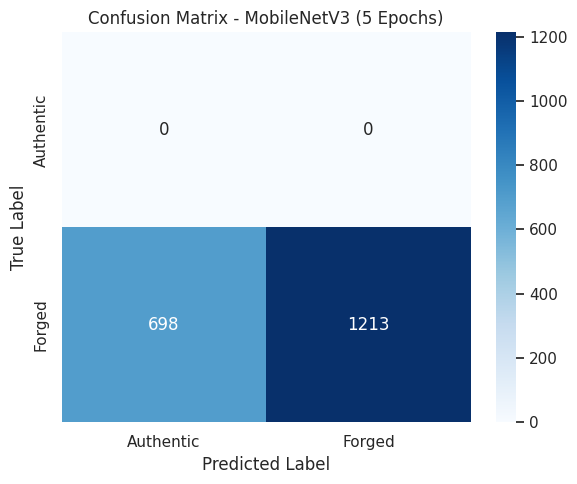

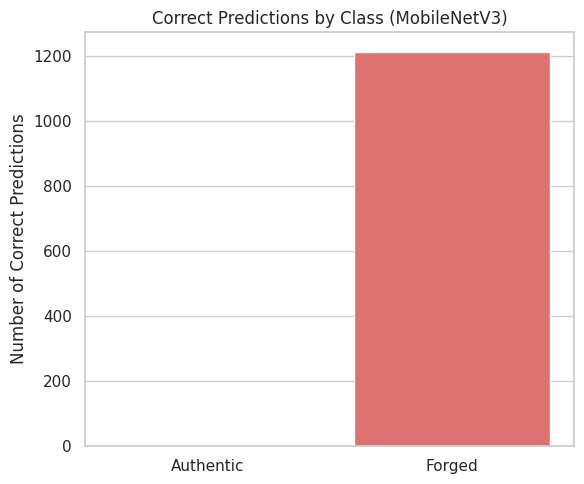

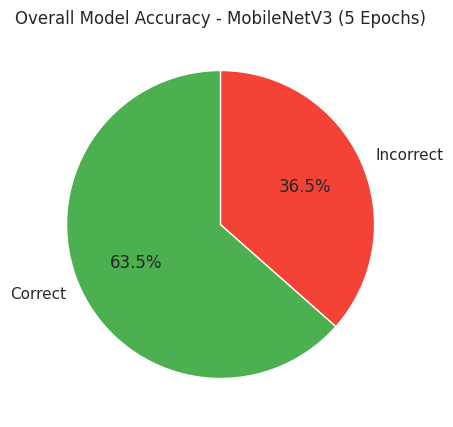


 ✅ ALL EVALUATIONS COMPLETE AND SAVED TO COLAB


In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Large
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Explicitly import all requested metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# 1. ARCHITECTURE: Advanced MobileNetV3 (Transfer Learning)
def build_mobilenetv3(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    # MobileNetV3 handles [0, 255] input scaling internally natively,
    # so we do not need an explicit preprocess_input function here.

    # Load pre-trained base
    base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_tensor=inputs)
    base_model.trainable = False # Freeze core brain

    # Custom classification layers
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name="MobileNetV3_Colab")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def run_colab_pipeline(dataset_path):
    # 2. Setup Parameters
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 5  # <--- UPDATED TO 5 EPOCHS
    WEIGHTS_FILE = f"MobileNetV3_epoch_{EPOCHS}.weights.h5"

    print("Loading training and validation datasets directly from Kaggle cache...")

    # 3. Load Data
    DATASET_INNER_FOLDER = "CASIA2"
    data_dir = os.path.join(dataset_path, DATASET_INNER_FOLDER)

    # Added class_names=['Au', 'Tp'] to explicitly ignore the Groundtruth folder
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=1337,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        class_names=['Au', 'Tp']
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=1337,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        shuffle=False,
        class_names=['Au', 'Tp']
    )

    # 4. Build Model
    model = build_mobilenetv3()

    print(f"\n🚀 Starting MobileNetV3 training for {EPOCHS} epochs...")

    # 5. Train the Model
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    # 6. Save the Weights
    model.save_weights(WEIGHTS_FILE)
    print(f"\n✅ Training complete! Weights saved as '{WEIGHTS_FILE}'")

    # =========================================================================
    # 7. EVALUATION & VISUALIZATION PHASE
    # =========================================================================
    print("\n📊 Generating Evaluation Metrics...\n")

    y_true = []
    y_pred_probs = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred_probs.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # --- RAW STATISTICAL TEXT OUTPUT ---
    print("=============== VISUALIZATION & METRICS ===============")
    print(f"Accuracy:      {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision:     {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:        {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:      {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_true, y_pred_probs):.4f}")

    print("\nConfusion Matrix (Raw Array):")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Authentic', 'Forged']))
    print("=======================================================\n")

    # --- Chart Generation ---
    sns.set_theme(style="whitegrid")
    cm = confusion_matrix(y_true, y_pred)

    # 1. Confusion Matrix Plot
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
    plt.title(f'Confusion Matrix - MobileNetV3 ({EPOCHS} Epochs)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_mobilenetv3_{EPOCHS}.png')
    plt.show()

    # 2. Bar Chart
    plt.figure(figsize=(6,5))
    categories = ['Authentic', 'Forged']
    correct = [cm[0,0], cm[1,1]]
    sns.barplot(x=categories, y=correct, hue=categories, palette='magma', legend=False)
    plt.title(f'Correct Predictions by Class (MobileNetV3)')
    plt.ylabel('Number of Correct Predictions')
    plt.tight_layout()
    plt.savefig(f'performance_barchart_mobilenetv3_{EPOCHS}.png')
    plt.show()

    # 3. Pie Chart
    plt.figure(figsize=(6,5))
    total_correct = np.sum(np.diag(cm))
    total_incorrect = len(y_true) - total_correct
    plt.pie([total_correct, total_incorrect], labels=['Correct', 'Incorrect'], autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
    plt.title(f'Overall Model Accuracy - MobileNetV3 ({EPOCHS} Epochs)')
    plt.savefig(f'prediction_piechart_mobilenetv3_{EPOCHS}.png')
    plt.show()

    print("\n==================================================")
    print(" ✅ ALL EVALUATIONS COMPLETE AND SAVED TO COLAB")
    print("==================================================")

    return y_true, y_pred, y_pred_probs, EPOCHS

# 8. Execute the Pipeline
if __name__ == "__main__":
    path = kagglehub.dataset_download("divg07/casia-20-image-tampering-detection-dataset")
    y_true, y_pred, y_pred_probs, EPOCHS = run_colab_pipeline(path)

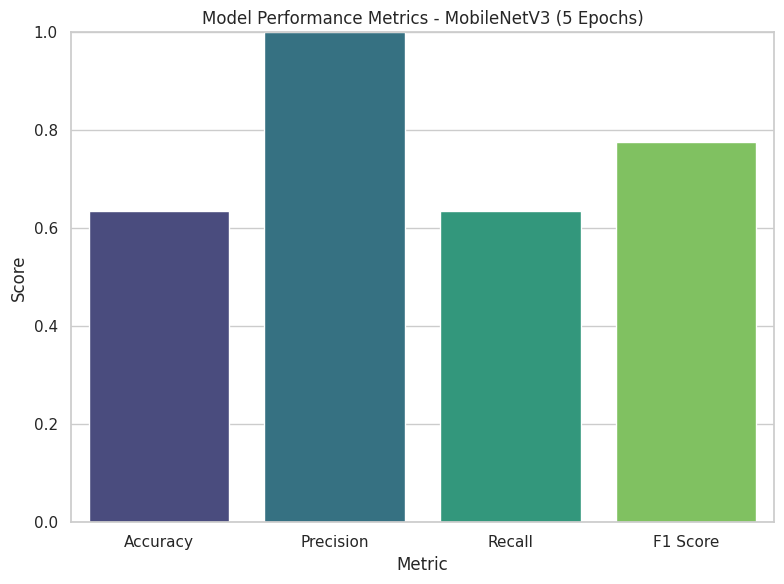

In [4]:
import pandas as pd

# Create a DataFrame for metrics
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy_score(y_true, y_pred), precision_score(y_true, y_pred), recall_score(y_true, y_pred), f1_score(y_true, y_pred)]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis', hue='Metric', legend=False)
plt.title(f'Model Performance Metrics - MobileNetV3 ({EPOCHS} Epochs)')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.tight_layout()
plt.savefig(f'performance_metrics_bar_mobilenetv3_{EPOCHS}.png')
plt.show()